In [1]:
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
print(data.data.shape)
print(data.target_names)

(569, 30)
['malignant' 'benign']


## Step 2: Quick Exploration

Checking the dataset's structure before modeling: feature names, target
classes, missing values, and class balance. The dataset has 30 numeric
features, 2 target classes (malignant/benign), and no missing values.
The classes are somewhat imbalanced (357 benign vs 212 malignant), which
means accuracy alone might not tell the full story later — recall per
class will matter too.

Feature names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
Target classes: ['malignant' 'benign']
Missing values: 0
target
1    357
0    212
Name: count, dtype: int64


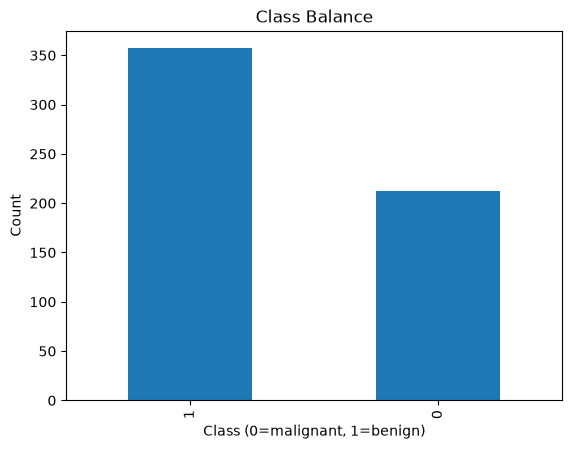

In [2]:
import matplotlib.pyplot as plt

# Feature and target names 
print("Feature names:", data.feature_names)
print("Target classes:", data.target_names)

# checking Missing values 
import pandas as pd
X = pd.DataFrame(data.data, columns=data.feature_names)
print("Missing values:", X.isnull().sum().sum())

# Class balance 
y = pd.Series(data.target, name="target")
print(y.value_counts())

y.value_counts().plot(kind='bar')
plt.title("Class Balance")
plt.xlabel("Class (0=malignant, 1=benign)")
plt.ylabel("Count")
plt.show()

## Step 3: Train/Test Split

Splitting the data into 80% train and 20% test, using the same random_state=42
for reproducibility. Using stratify=y to keep the class ratio (malignant vs
benign) consistent in both train and test sets. Both models will use this
exact same split so the comparison between them is fair.

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (455, 30)
Test size: (114, 30)


## Step 4: Train Two Models

Training two baseline classifiers on the same training data:
- Model A: Logistic Regression (linear model, predicts probability of each class)
- Model B: Decision Tree (rule-based splits, like a flowchart of if-else conditions)

Both use default parameters except random_state=42 for reproducibility.
Neither model touches the test set at this stage.

Note: Added StandardScaler for Logistic Regression since it had convergence
issues with unscaled features (different features had very different ranges).
Fit only on train, then applied to test — no leakage.

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler

# Scale features (fit on TRAIN only, transform both)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model A: Logistic Regression (using scaled data)
model_a = LogisticRegression(max_iter=1000)
model_a.fit(X_train_scaled, y_train)

# Model B: Decision Tree (scaling doesn't matter for trees, but harmless)
model_b = DecisionTreeClassifier(random_state=42)
model_b.fit(X_train, y_train)

print("Both models trained successfully!")

Both models trained successfully!


## Step 5: Evaluate on Test Set

Evaluating both models on the held-out test set (data neither model has
seen). Reporting accuracy, precision, recall, F1-score, and confusion
matrix for each model.

In [5]:
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predictions
pred_a = model_a.predict(X_test_scaled)   # Logistic Regression uses scaled test data
pred_b = model_b.predict(X_test)          # Decision Tree uses normal test data

# Accuracy
print("Logistic Regression Accuracy:", accuracy_score(y_test, pred_a))
print("Decision Tree Accuracy:", accuracy_score(y_test, pred_b))

print("\n--- Logistic Regression Report ---")
print(classification_report(y_test, pred_a))

print("\n--- Decision Tree Report ---")
print(classification_report(y_test, pred_b))

Logistic Regression Accuracy: 0.9824561403508771
Decision Tree Accuracy: 0.9122807017543859

--- Logistic Regression Report ---
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


--- Decision Tree Report ---
              precision    recall  f1-score   support

           0       0.85      0.93      0.89        42
           1       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114



## Step 6: Visualize the Comparison

1-Side-by-side confusion matrices
2-Grouped bar chart comparing all 4 metrics (accuracy, precision, recall, F1)
side by side for both models.

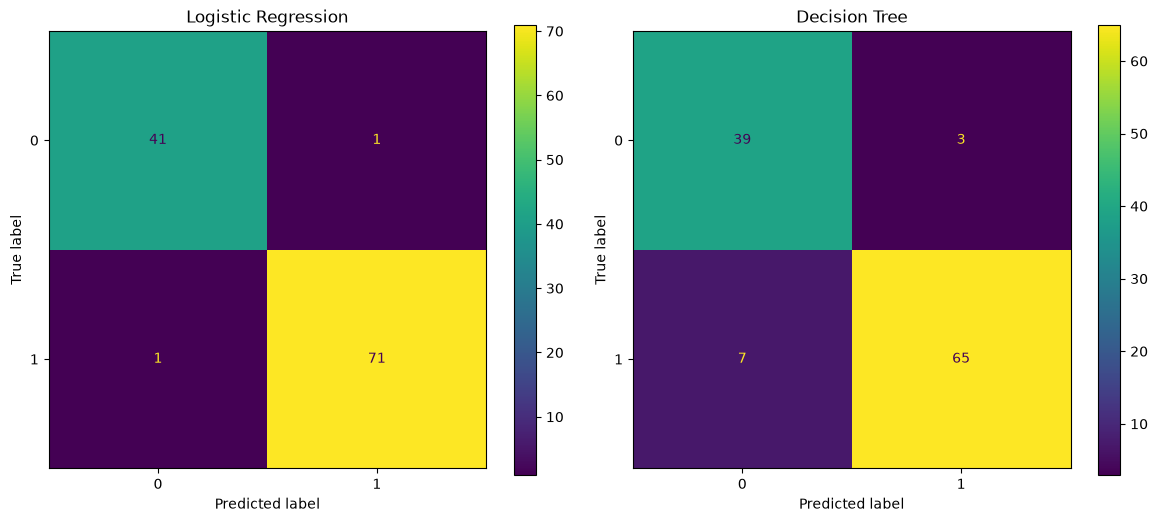

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(y_test, pred_a, ax=axes[0])
axes[0].set_title("Logistic Regression")

ConfusionMatrixDisplay.from_predictions(y_test, pred_b, ax=axes[1])
axes[1].set_title("Decision Tree")

plt.tight_layout()
plt.show()

In [7]:
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Logistic Regression": [
        accuracy_score(y_test, pred_a),
        precision_score(y_test, pred_a),
        recall_score(y_test, pred_a),
        f1_score(y_test, pred_a)
    ],
    "Decision Tree": [
        accuracy_score(y_test, pred_b),
        precision_score(y_test, pred_b),
        recall_score(y_test, pred_b),
        f1_score(y_test, pred_b)
    ]
})
print(results)


      Metric  Logistic Regression  Decision Tree
0   Accuracy             0.982456       0.912281
1  Precision             0.986111       0.955882
2     Recall             0.986111       0.902778
3   F1-score             0.986111       0.928571


In [8]:
print("LogReg Recall (malignant):", recall_score(y_test, pred_a, pos_label=0))
print("Tree Recall (malignant):", recall_score(y_test, pred_b, pos_label=0))

LogReg Recall (malignant): 0.9761904761904762
Tree Recall (malignant): 0.9285714285714286


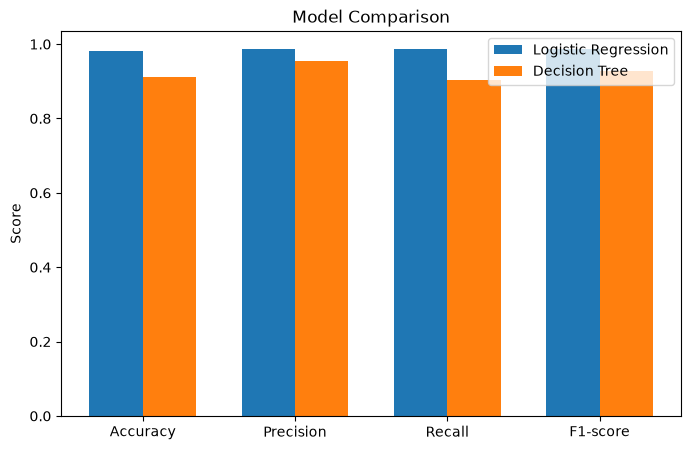

In [9]:
import numpy as np

metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
a_scores = results["Logistic Regression"].values
b_scores = results["Decision Tree"].values

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8,5))
ax.bar(x - width/2, a_scores, width, label='Logistic Regression')
ax.bar(x + width/2, b_scores, width, label='Decision Tree')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel("Score")
ax.set_title("Model Comparison")
ax.legend()
plt.show()

## Step 7: Conclusion

Logistic Regression performed better overall, achieving 98.25% accuracy
compared to Decision Tree's 91.23%, and it outperformed on every other
metric too, not just accuracy. The errors were different in kind as well:
out of 114 test cases, Logistic Regression only got 2 wrong while Decision
Tree got 10 wrong, five times more mistakes. More importantly, Logistic
Regression missed only 1 actual cancer case, while Decision Tree missed 3.
In medicine, missing a real cancer case is the worst kind of mistake you
can make, since a false negative means the patient doesn't get treated in
time, whereas a false positive just means extra testing. This is why
recall matters more than precision for this problem, and Logistic
Regression's recall for malignant cases (97.6%) was clearly higher than
Decision Tree's (92.9%). Given this, Logistic Regression is the model I
would ship, since it is simply the safer and more accurate choice here.
To improve things further, I would try cross-validation to double-check
these results, limit how deep the Decision Tree can grow to reduce
overfitting, or test a Random Forest, which usually handles this kind of
overfitting better.


## Final Summary

This project compared Logistic Regression and Decision Tree classifiers
on the Breast Cancer Wisconsin dataset (569 samples, 30 features, binary
classification: malignant vs benign) using an 80/20 train-test split with
random_state=42 for reproducibility. Logistic Regression achieved 98.25%
accuracy and 97.6% recall on malignant cases, compared to Decision Tree's
91.23% accuracy and 92.9% recall. Logistic Regression also produced far
fewer false negatives (1 vs 3), which is critical in a medical diagnosis
context. Based on these results, Logistic Regression is the recommended
model for this task.

## Bonus 1: 5-Fold Cross-Validation

Running 5-fold cross-validation on both models using the full dataset to
get a more robust estimate of performance, rather than relying on a single
train-test split.


In [10]:
from sklearn.model_selection import cross_val_score

# Note: For Logistic Regression, we scale the full X here since 
# cross_val_score handles the splitting internally
X_scaled_full = scaler.fit_transform(X)

cv_scores_a = cross_val_score(LogisticRegression(max_iter=1000), X_scaled_full, y, cv=5)
cv_scores_b = cross_val_score(DecisionTreeClassifier(random_state=42), X, y, cv=5)

print("Logistic Regression CV scores:", cv_scores_a)
print("Logistic Regression CV mean:", cv_scores_a.mean())
print()
print("Decision Tree CV scores:", cv_scores_b)
print("Decision Tree CV mean:", cv_scores_b.mean())

Logistic Regression CV scores: [0.98245614 0.98245614 0.97368421 0.97368421 0.99115044]
Logistic Regression CV mean: 0.9806862288464524

Decision Tree CV scores: [0.9122807  0.90350877 0.92982456 0.95614035 0.88495575]
Decision Tree CV mean: 0.9173420276354604


## Bonus 2: Random Forest (Third Model)

Adding a Random Forest classifier for comparison. Random Forest builds
many decision trees on random subsets of data and averages their
predictions, which typically reduces overfitting compared to a single
Decision Tree.

In [11]:
from sklearn.ensemble import RandomForestClassifier

model_c = RandomForestClassifier(random_state=42)
model_c.fit(X_train, y_train)

pred_c = model_c.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, pred_c))
print(classification_report(y_test, pred_c))

Random Forest Accuracy: 0.956140350877193
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



## Bonus 3: Hyperparameter Tuning (Decision Tree max_depth)

Testing different max_depth values for the Decision Tree using
cross-validation on the training data only, to see if limiting tree
depth reduces overfitting and improves generalization. The test set
is not touched during this tuning process.


In [12]:
depths = [2, 3, 4, 5, 6, None]

for d in depths:
    tree = DecisionTreeClassifier(max_depth=d, random_state=42)
    scores = cross_val_score(tree, X_train, y_train, cv=5)
    print(f"max_depth={d}: CV mean accuracy = {scores.mean():.4f}")
    

max_depth=2: CV mean accuracy = 0.9187
max_depth=3: CV mean accuracy = 0.9253
max_depth=4: CV mean accuracy = 0.9385
max_depth=5: CV mean accuracy = 0.9319
max_depth=6: CV mean accuracy = 0.9187
max_depth=None: CV mean accuracy = 0.9099


In [13]:
best_tree = DecisionTreeClassifier(max_depth=4, random_state=42)
best_tree.fit(X_train, y_train)
pred_best_tree = best_tree.predict(X_test)

print("Tuned Decision Tree (max_depth=4) Accuracy:", accuracy_score(y_test, pred_best_tree))
print(classification_report(y_test, pred_best_tree))



Tuned Decision Tree (max_depth=4) Accuracy: 0.9385964912280702
              precision    recall  f1-score   support

           0       0.91      0.93      0.92        42
           1       0.96      0.94      0.95        72

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114



## Updated Final Summary with Bonus Tasks

This project compared Logistic Regression and Decision Tree classifiers
on the Breast Cancer Wisconsin dataset (569 samples, 30 features, binary
classification: malignant vs benign) using an 80/20 train-test split with
random_state=42 for reproducibility. Logistic Regression achieved 98.25%
accuracy and 97.6% recall on malignant cases, compared to Decision Tree's
91.23% accuracy and 92.9% recall. Logistic Regression also produced far
fewer false negatives (1 vs 3), which is critical in a medical diagnosis
context. As a bonus, 5-fold cross-validation confirmed these results were
consistent (LogReg: 98.07% mean, Tree: 91.73% mean), a Random Forest
model improved on the single Decision Tree (95.6% accuracy), and tuning
the Decision Tree's max_depth to 4 further improved it to 93.86% accuracy
— though it still did not surpass Logistic Regression. Based on all
results, Logistic Regression is the recommended model for this task.